,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600


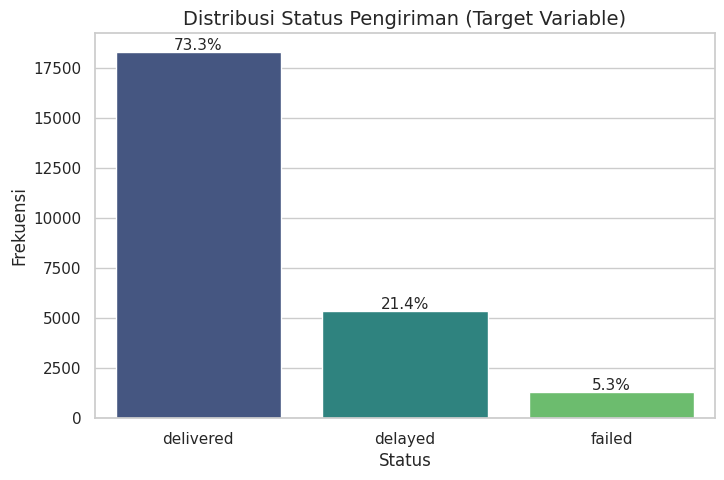

,distance_km,package_weight_kg,delivery_cost,delivery_time_hours
count,25000.00,25000.00,25000.00,25000.00
mean,150.39,25.15,864.94,6.25
std,86.41,14.37,435.71,3.14
min,3.60,0.67,95.67,0.00
25%,75.90,12.68,490.80,4.00
50%,151.00,25.14,867.54,6.00
75%,224.90,37.66,1237.91,8.00
max,297.10,49.52,1632.72,19.00


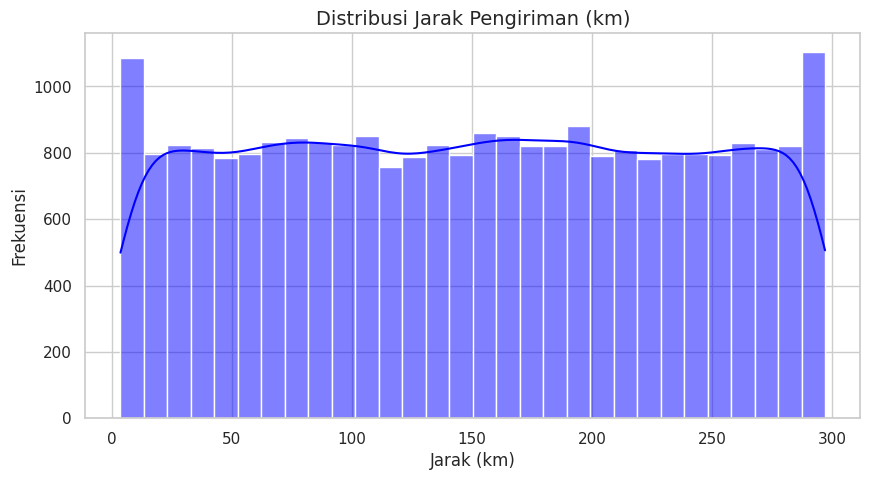

In [5]:

# # 01. Strategic Analytics & Descriptive Statistics
#
# ## Objektif Analitik
# Notebook ini difokuskan pada eksplorasi univariat untuk memahami distribusi dasar dari data logistik yang telah dibersihkan. Tahapan ini mencakup inspeksi statistik deskriptif, analisis distribusi kelas target, serta pemetaan profil variabel operasional utama seperti jarak dan berat paket.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Memuat dataset yang telah dibersihkan (Processed Data)
df_clean = pd.read_csv('/content/Delivery_Logistics_Clean.csv')

# Menampilkan 5 baris pertama untuk verifikasi integritas data
display(df_clean.head())


# ## 1. Analisis Distribusi Target (Target Variable Distribution)
# Mengevaluasi proporsi status pengiriman untuk mendeteksi potensi ketidakseimbangan kelas (*class imbalance*) yang dapat mempengaruhi metrik evaluasi model di tahap selanjutnya.

# %%
# Visualisasi distribusi kelas target 'delivery_status'
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df_clean, x='delivery_status', hue='delivery_status', palette='viridis', order=df_clean['delivery_status'].value_counts().index, legend=False)

plt.title('Distribusi Status Pengiriman (Target Variable)', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Menambahkan anotasi persentase
total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), ha='center', fontsize=11)

plt.show()


# ## 2. Statistik Deskriptif Fitur Numerik
# Mengidentifikasi ukuran pemusatan (mean, median) dan penyebaran (standar deviasi, rentang) untuk mendeteksi adanya *outlier* pada variabel biaya, jarak, dan berat.

# %%
# Menghasilkan ringkasan statistik
numeric_cols = ['distance_km', 'package_weight_kg', 'delivery_cost', 'delivery_time_hours']
display(df_clean[numeric_cols].describe().round(2))

# Visualisasi distribusi jarak tempuh (distance_km)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['distance_km'], bins=30, kde=True, color='blue')
plt.title('Distribusi Jarak Pengiriman (km)', fontsize=14)
plt.xlabel('Jarak (km)')
plt.ylabel('Frekuensi')
plt.show()